# Afya Oracle — Level 1 CDI Data Pipeline
### Google Earth Engine → Feature Extraction → Training Dataset
**Pilot States:** Unity, Jonglei, Upper Nile | **Facilities:** 93 PHCCs | **Period:** 2019–2024

## Install & Authenticate GEE

In [29]:
!pip install earthengine-api -q

import ee
import pandas as pd
import numpy as np

# Authenticate — click the link that appears, sign in, paste token back
ee.Authenticate()
ee.Initialize(project='seraphic-heaven-419508')
print('GEE connected ✅')

GEE connected ✅


In [30]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Load Your Real Facility Data from XLS

In [31]:
# Load your actual MOH facility list from Google Drive
df = pd.read_excel(
    '/content/drive/MyDrive/Afya_Oracle/list_hf_ss_moh_update_v1_20160404.xls',
    engine='xlrd'
)

# Filter to pilot states — PHCCs only
pilot_states = ['Unity', 'Jonglei', 'Upper Nile']
df_pilot = df[
    (df['STATE'].isin(pilot_states)) &
    (df['HF_TYPE'] == 'PHCC')
].copy()

# Clean coordinates
df_pilot = df_pilot[
    (df_pilot['LATITUDE'] != 0) &
    (df_pilot['LONGITUDE'] != 0) &
    (df_pilot['LATITUDE'].notna()) &
    (df_pilot['LONGITUDE'].notna())
].reset_index(drop=True)

print(f'Total pilot PHCCs: {len(df_pilot)}')
print(df_pilot[['FACIL_NAME', 'STATE', 'COUNTY', 'LATITUDE', 'LONGITUDE']].to_string(index=False))

Total pilot PHCCs: 93
               FACIL_NAME      STATE         COUNTY  LATITUDE  LONGITUDE
              Walgak PHCC    Jonglei          Akobo  8.160750  32.238650
                Ayod PHCC    Jonglei           Ayod  8.122810  31.413560
               Mogok PHCU    Jonglei           Ayod  8.402390  31.336460
               Pagil PHCU    Jonglei           Ayod  8.710850  31.269250
          Ascom Ayod PHCC    Jonglei           Ayod  8.135440  31.409710
          Wan Machar PHCC    Jonglei           Ayod  8.231990  30.594330
              Baidit PHCC    Jonglei            Bor  6.429510  31.562560
               Jalle PHCC    Jonglei            Bor  6.671820  31.776590
            Kolnyang PHCC    Jonglei            Bor  6.137080  31.731850
    Malual Agor Baar PHCC    Jonglei            Bor  6.125380  31.580840
              Pariak PHCC    Jonglei            Bor  5.971020  31.660660
              Makuac PHCC    Jonglei            Bor  6.261550  31.730800
              Anyidi PHCU    

## Facility Data Analysis and Visualization

/tmp/ipykernel_1894/539526296.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='STATE', data=df_pilot, order=df_pilot['STATE'].value_counts().index, palette='viridis')


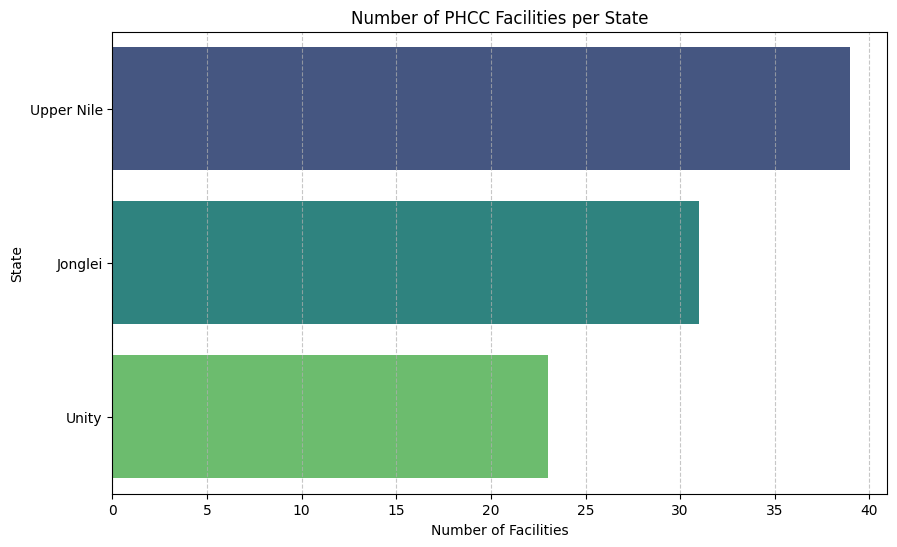

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of facilities by State
plt.figure(figsize=(10, 6))
sns.countplot(y='STATE', data=df_pilot, order=df_pilot['STATE'].value_counts().index, palette='viridis')
plt.title('Number of PHCC Facilities per State')
plt.xlabel('Number of Facilities')
plt.ylabel('State')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipykernel_1894/2188460879.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='COUNTY', data=df_pilot, order=df_pilot['COUNTY'].value_counts().index, palette='magma')


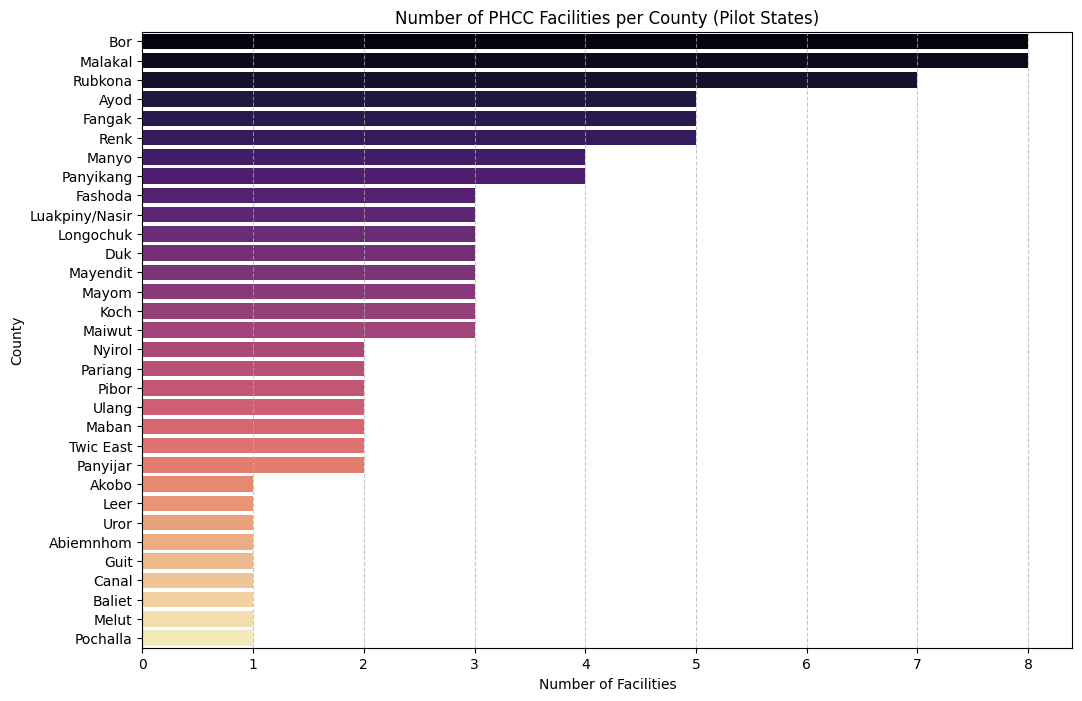

In [33]:
# Distribution of facilities by County within pilot states
plt.figure(figsize=(12, 8))
sns.countplot(y='COUNTY', data=df_pilot, order=df_pilot['COUNTY'].value_counts().index, palette='magma')
plt.title('Number of PHCC Facilities per County (Pilot States)')
plt.xlabel('Number of Facilities')
plt.ylabel('County')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

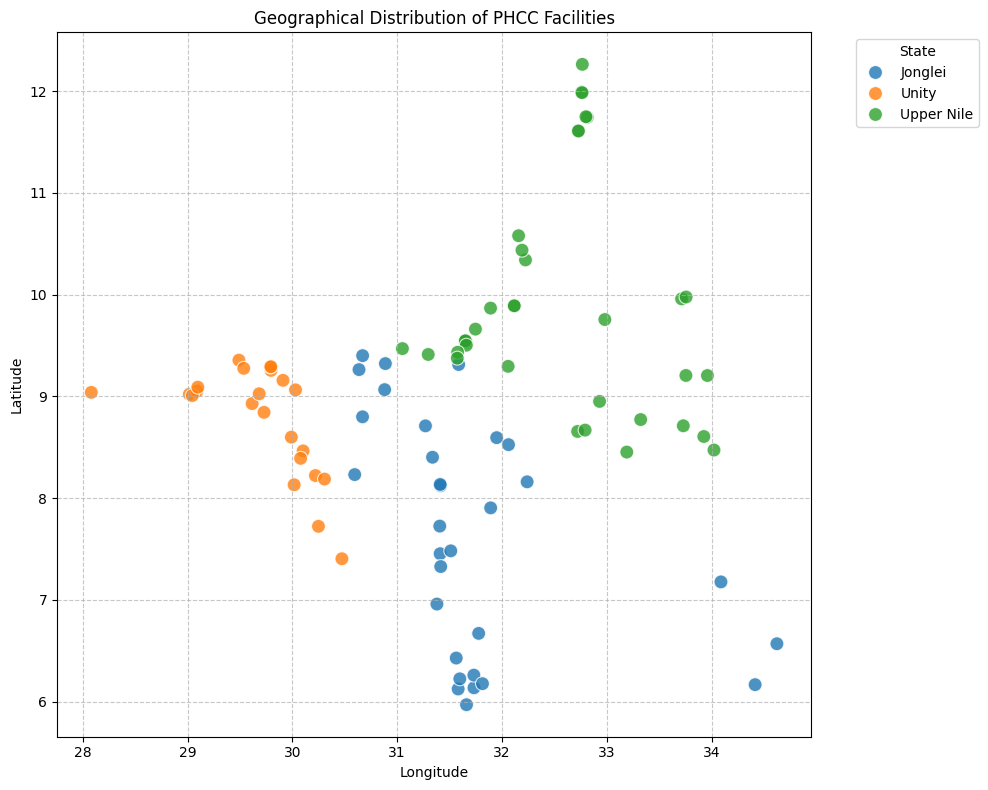

In [34]:
# Geographical distribution of facilities
plt.figure(figsize=(10, 8))
sns.scatterplot(x='LONGITUDE', y='LATITUDE', hue='STATE', data=df_pilot, s=100, alpha=0.8)
plt.title('Geographical Distribution of PHCC Facilities')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='State', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Summary Statistics for Facility Coordinates

In [35]:
print(df_pilot[['LATITUDE', 'LONGITUDE']].describe())

        LATITUDE  LONGITUDE
count  93.000000  93.000000
mean    8.853484  31.548729
std     1.378836   1.387705
min     5.971020  28.082340
25%     8.187980  30.594330
50%     9.026190  31.646730
75%     9.503280  32.238650
max    12.262920  34.620810


### Functional Status Analysis

In [36]:
if 'FUNCTIONAL Status' in df_pilot.columns:
    functional_status_counts = df_pilot['FUNCTIONAL Status'].value_counts()
    functional_status_percentages = df_pilot['FUNCTIONAL Status'].value_counts(normalize=True) * 100

    print('Counts of Functional Status:')
    print(functional_status_counts)
    print('\nPercentages of Functional Status:')
    print(functional_status_percentages)
else:
    print("The 'FUNCTIONAL Status' column was not found in the DataFrame.")

Counts of Functional Status:
FUNCTIONAL Status
Functional    10
Name: count, dtype: int64

Percentages of Functional Status:
FUNCTIONAL Status
Functional    100.0
Name: proportion, dtype: float64


/tmp/ipykernel_1894/542125352.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='STATE', y='Count', data=functional_by_state, palette='viridis')


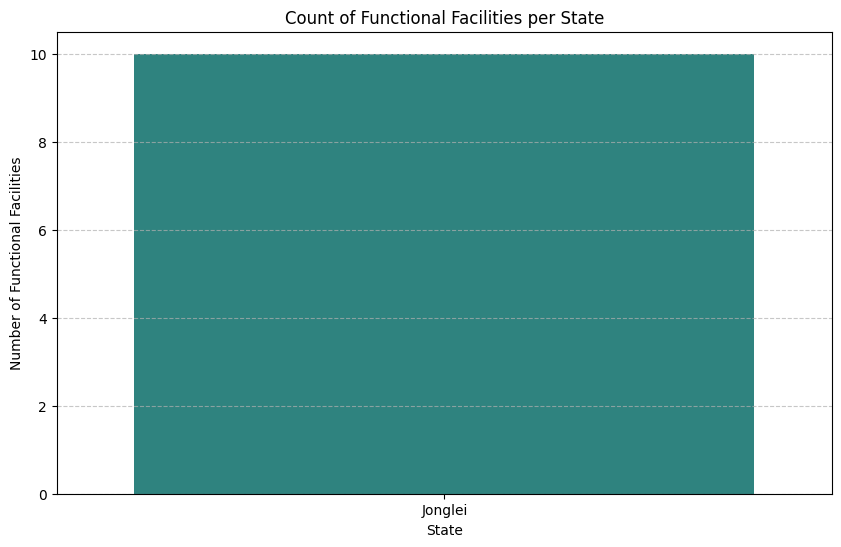


Functional Facilities by State:
  STATE  Count
Jonglei     10


In [37]:
if 'FUNCTIONAL Status' in df_pilot.columns:
    functional_by_state = df_pilot[df_pilot['FUNCTIONAL Status'] == 'Functional'].groupby('STATE').size().reset_index(name='Count')

    plt.figure(figsize=(10, 6))
    sns.barplot(x='STATE', y='Count', data=functional_by_state, palette='viridis')
    plt.title('Count of Functional Facilities per State')
    plt.xlabel('State')
    plt.ylabel('Number of Functional Facilities')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    print('\nFunctional Facilities by State:')
    print(functional_by_state.to_string(index=False))
else:
    print("The 'FUNCTIONAL Status' column was not found in the DataFrame.")

In [38]:
##

## Build GEE Feature Collection from Real Facilities

In [39]:
features = []
for _, row in df_pilot.iterrows():
    point = ee.Geometry.Point([row['LONGITUDE'], row['LATITUDE']])
    feature = ee.Feature(point, {
        'facility_name': str(row['FACIL_NAME']),
        'state':         str(row['STATE']),
        'county':        str(row['COUNTY']),
        'latitude':      float(row['LATITUDE']),
        'longitude':     float(row['LONGITUDE'])
    })
    features.append(feature)

fc = ee.FeatureCollection(features)
print(f'Feature collection created: {fc.size().getInfo()} facilities ✅')

Feature collection created: 93 facilities ✅


## Export Sentinel-1 SAR (Flood Signal)

In [40]:
def extract_s1(facility_feature):
    point = facility_feature.geometry()
    s1 = (ee.ImageCollection('COPERNICUS/S1_GRD')
          .filterBounds(point)
          .filterDate('2019-01-01', '2024-12-31')
          .filter(ee.Filter.eq('instrumentMode', 'IW'))
          .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
          .filter(ee.Filter.eq('orbitProperties_pass', 'DESCENDING'))
          .select('VV'))

    def extract_per_image(image):
        val = image.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=point.buffer(500),
            scale=10
        )
        return ee.Feature(None, {
            'facility_name':  facility_feature.get('facility_name'),
            'state':          facility_feature.get('state'),
            'county':         facility_feature.get('county'),
            'latitude':       facility_feature.get('latitude'),
            'longitude':      facility_feature.get('longitude'),
            'date':           image.date().format('YYYY-MM-dd'),
            'VV_backscatter': val.get('VV')
        })
    return s1.map(extract_per_image)

all_s1 = fc.map(lambda f: extract_s1(f)).flatten()

task_s1 = ee.batch.Export.table.toDrive(
    collection=all_s1,
    description='SSD_Sentinel1_VV_2019_2024',
    fileFormat='CSV',
    folder='Afya_Oracle'
)
task_s1.start()
print('Sentinel-1 export started ✅')
print('Status:', task_s1.status()['state'])

Sentinel-1 export started ✅
Status: READY


## Export NASA IMERG Rainfall

In [41]:
print('IMERG Rainfall data export skipped as requested.')
# Original IMERG export code (commented out due to user request):
# def extract_imerg(facility_feature):
#     point = facility_feature.geometry()
#     imerg = (ee.ImageCollection('NASA/GPM_L3/IMERG_V07')
#              .filterBounds(point)
#              .filterDate('2019-01-01', '2024-12-31')
#              .select('precipitation'))

#     def extract_per_image(image):
#         val = image.reduceRegion(
#             reducer=ee.Reducer.mean(),
#             geometry=point.buffer(500),
#             scale=11132
#         )
#         return ee.Feature(None, {
#             'facility_name':  facility_feature.get('facility_name'),
#             'state':          facility_feature.get('state'),
#             'date':           image.date().format('YYYY-MM-dd'),
#             'rainfall_mm_hr': val.get('precipitation')
#         })
#     return imerg.map(extract_per_image)

# all_imerg = fc.map(lambda f: extract_imerg(f)).flatten()

# task_imerg = ee.batch.Export.table.toDrive(
#     collection=all_imerg,
#     description='SSD_IMERG_Rainfall_2019_2024',
#     fileFormat='CSV',
#     folder='Afya_Oracle'
# )
# task_imerg.start()
# print('IMERG export started ✅')
# print('Status:', task_imerg.status()['state'])

IMERG Rainfall data export skipped as requested.


## Export SRTM Elevation (Static)

In [42]:
srtm = ee.Image('USGS/SRTMGL1_003')

def extract_srtm(facility_feature):
    point = facility_feature.geometry()
    val = srtm.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=point.buffer(500),
        scale=30
    )
    return ee.Feature(None, {
        'facility_name': facility_feature.get('facility_name'),
        'state':         facility_feature.get('state'),
        'county':        facility_feature.get('county'),
        'latitude':      facility_feature.get('latitude'),
        'longitude':     facility_feature.get('longitude'),
        'elevation_m':   val.get('elevation')
    })

srtm_features = fc.map(extract_srtm)

task_srtm = ee.batch.Export.table.toDrive(
    collection=srtm_features,
    description='SSD_SRTM_Elevation',
    fileFormat='CSV',
    folder='Afya_Oracle'
)
task_srtm.start()
print('SRTM export started ✅')
print('Status:', task_srtm.status()['state'])

SRTM export started ✅
Status: READY


## Export ERA5 Temperature (Cold Chain Risk)

In [15]:
def extract_era5(facility_feature):
    point = facility_feature.geometry()
    era5 = (ee.ImageCollection('ECMWF/ERA5_LAND/DAILY_AGGR')
            .filterBounds(point)
            .filterDate('2019-01-01', '2024-12-31')
            .select('temperature_2m_max'))

    def extract_per_image(image):
        temp_c = image.subtract(273.15)  # Kelvin to Celsius
        val = temp_c.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=point.buffer(500),
            scale=11132
        )
        return ee.Feature(None, {
            'facility_name':   facility_feature.get('facility_name'),
            'state':           facility_feature.get('state'),
            'date':            image.date().format('YYYY-MM-dd'),
            'temp_max_celsius': val.get('temperature_2m_max')
        })
    return era5.map(extract_per_image)

all_era5 = fc.map(lambda f: extract_era5(f)).flatten()

task_era5 = ee.batch.Export.table.toDrive(
    collection=all_era5,
    description='SSD_ERA5_Temperature_2019_2024',
    fileFormat='CSV',
    folder='Afya_Oracle'
)
task_era5.start()
print('ERA5 export started ✅')
print('Status:', task_era5.status()['state'])

ERA5 export started ✅
Status: READY


## Monitor All Export Tasks

In [16]:
# Run this cell repeatedly until all say COMPLETED
tasks = {
    'Sentinel-1':      task_s1,
    'SRTM Elevation':  task_srtm,
    'ERA5 Temperature': task_era5
}

for name, t in tasks.items():
    print(f'{name}: {t.status()["state"]}')

Sentinel-1: RUNNING
SRTM Elevation: COMPLETED
ERA5 Temperature: RUNNING


## Load All CSVs from Input

In [43]:
import os

# Update this path to your actual dataset path in Google Drive
base = '/content/drive/MyDrive/Afya_Oracle'

print('Files available in Drive:')
if os.path.exists(base):
    for f in os.listdir(base):
        print(' -', f)

    s1_df   = pd.read_csv(base + '/' + 'SSD_Sentinel1_VV_2019_2024.csv')
    srtm_df = pd.read_csv(base + '/' + 'SSD_SRTM_Elevation.csv')
    # Using v2 as per previous logs
    era5_df  = pd.read_csv(base + '/' + 'SSD_ERA5_Temperature_2019_2024_v2.csv')

    print('\nShapes:')
    print(f'  Sentinel-1: {s1_df.shape}')
    print(f'  SRTM:       {srtm_df.shape}')
    print(f'  ERA5:       {era5_df.shape}')
else:
    print(f'Directory {base} not found. Please ensure Drive is mounted and folder exists.')

Files available in Drive:
 - list_hf_ss_moh_update_v1_20160404.xls
 - SSD_SRTM_Elevation.csv
 - SSD_Sentinel1_VV_2019_2024 (1).csv
 - SSD_Sentinel1_VV_2019_2024.gsheet
 - SSD_ERA5_Temperature_2019_2024_v2.csv
 - SSD_ERA5_Temperature_2019_2024_v2.gsheet
 - SSD_Sentinel1_VV_2019_2024.csv
 - SSD_ERA5_Temperature_2019_2024.csv

Shapes:
  Sentinel-1: (18224, 9)
  SRTM:       (93, 8)
  ERA5:       (203763, 5)


## Clean & Merge All Datasets

In [46]:
# ── Clean S1 ────────────────────────────────────────────────────────────────
s1_df = s1_df[['facility_name', 'state', 'county',
                'latitude', 'longitude', 'date', 'VV_backscatter']].copy()
s1_df['date'] = pd.to_datetime(s1_df['date'])
s1_df = s1_df.dropna(subset=['VV_backscatter'])

# ── Clean SRTM ───────────────────────────────────────────────────────────────
srtm_df = srtm_df[['facility_name', 'elevation_m']].copy()
srtm_df = srtm_df.dropna(subset=['elevation_m'])

# ── Clean ERA5 ───────────────────────────────────────────────────────────────
era_col = 'temp_max_celsius'
if era_col in era5_df.columns:
    era5_df = era5_df[['facility_name', 'date', era_col]].copy()
    era5_df['date'] = pd.to_datetime(era5_df['date'])
    era5_df = era5_df.dropna(subset=[era_col])

    # Aggregate ERA5 to weekly max temperature
    era5_df['week'] = era5_df['date'].dt.to_period('W').dt.start_time
    era5_weekly = era5_df.groupby(['facility_name', 'week']).agg(
        temp_max_7day=(era_col, 'max')
    ).reset_index()
else:
    print(f'Warning: {era_col} not found in ERA5 data. Creating empty placeholder.')
    era5_weekly = pd.DataFrame(columns=['facility_name', 'week', 'temp_max_7day'])

# ── Merge all ───────────────────────────────────────────────────────────────
# Create merge key in S1
s1_df['week'] = s1_df['date'].dt.to_period('W').dt.start_time

# Merge
df = s1_df.merge(srtm_df, on='facility_name', how='left')
df = df.merge(era5_weekly, on=['facility_name', 'week'], how='left')

print('Merged dataset shape:', df.shape)
print('Null counts:')
cols_to_check = ['VV_backscatter', 'elevation_m']
if 'temp_max_7day' in df.columns: cols_to_check.append('temp_max_7day')
print(df[cols_to_check].isnull().sum())

Merged dataset shape: (18223, 10)
Null counts:
VV_backscatter        0
elevation_m           0
temp_max_7day     18223
dtype: int64


In [47]:
print(era5_df.columns)

Index(['system:index', 'date', 'facility_name', 'state', '.geo'], dtype='object')


## Feature Engineering

In [48]:
df = df.sort_values(['facility_name', 'date']).reset_index(drop=True)

# ── Sentinel-1 features ──────────────────────────────────────────────────────
# Rolling mean VV (3 observations ≈ 3 weeks)
df['VV_7day_mean'] = df.groupby('facility_name')['VV_backscatter'].transform(
    lambda x: x.rolling(3, min_periods=1).mean()
)
# Change in VV from last observation (negative delta = water appearing)
df['VV_delta'] = df.groupby('facility_name')['VV_backscatter'].transform(
    lambda x: x.diff()
)
# Strong water signal threshold for South Sudan flood plains
df['flood_signal'] = (df['VV_backscatter'] < -15).astype(int)

# ── Elevation features ───────────────────────────────────────────────────────
# Facilities below 400m are in the Sudd flood plain
df['low_elevation'] = (df['elevation_m'] < 400).astype(int)

# ── Rainfall features ────────────────────────────────────────────────────────
# Rainfall features are excluded as requested
# df['heavy_rain'] = (df['rainfall_7day_mm'] > 50).astype(int)  # >50mm/week
# df['rainfall_anomaly'] = df.groupby(
#     ['facility_name', df['date'].dt.month]
# )['rainfall_7day_mm'].transform(
#     lambda x: (x - x.mean()) / (x.std() + 1e-6)
# )

# ── Temperature features (Cold Chain) ────────────────────────────────────────
# Vaccines at risk above 34°C sustained
df['ccf_risk'] = (df['temp_max_7day'] > 34).astype(int)
# Cumulative heat above 8°C (cold chain formula from whitepaper)
df['heat_exposure'] = (df['temp_max_7day'] - 8).clip(lower=0)

# ── Seasonal encoding ────────────────────────────────────────────────────────
df['day_of_year'] = df['date'].dt.dayofyear
df['season_sin']  = np.sin(2 * np.pi * df['day_of_year'] / 365)
df['season_cos']  = np.cos(2 * np.pi * df['day_of_year'] / 365)
# South Sudan rainy season: April–November
df['rainy_season'] = df['date'].dt.month.between(4, 11).astype(int)
df['year']  = df['date'].dt.year
df['month'] = df['date'].dt.month

print('Features created ✅')
print(df[['VV_backscatter', 'VV_7day_mean', 'VV_delta',
          'elevation_m', 'temp_max_7day',
          'flood_signal', 'ccf_risk']].describe().round(3))

Features created ✅
       VV_backscatter  VV_7day_mean   VV_delta  elevation_m  flood_signal  \
count       18223.000     18223.000  18130.000    18223.000     18223.000   
mean          -11.277       -11.286      0.008      412.218         0.051   
std             2.139         2.052      1.048       31.407         0.220   
min           -19.718       -18.758     -7.505      385.364         0.000   
25%           -12.773       -12.698     -0.455      397.746         0.000   
50%           -11.133       -11.134     -0.063      401.793         0.000   
75%            -9.572        -9.676      0.381      414.545         0.000   
max            -4.784        -5.121      6.887      681.142         1.000   

       ccf_risk  
count   18223.0  
mean        0.0  
std         0.0  
min         0.0  
25%         0.0  
50%         0.0  
75%         0.0  
max         0.0  


## Create Proxy Disruption Label
*(Replace with UNOSAT ground truth labels once downloaded from HDX)*

In [49]:
# Proxy label: facility likely disrupted if:
# - Strong flood signal (VV < -17 dB)
# - During rainy season
# - Low elevation (flood plain)
# - Heavy rainfall that week (THIS IS NOW EXCLUDED)
# This is conservative — real UNOSAT labels will replace this

df['disrupted'] = (
    (df['VV_backscatter'] < -17) &
    (df['rainy_season'] == 1) &
    (df['low_elevation'] == 1)
    # Removed rainfall condition: & (df['rainfall_7day_mm'] > 30)
).astype(int)

print('── Label Distribution ──────────────────────────')
print(f'Disrupted:     {df["disrupted"].sum():,}')
print(f'Not disrupted: {(df["disrupted"]==0).sum():,}')
print(f'Disruption rate: {df["disrupted"].mean()*100:.2f}%')

print('\n── By State ────────────────────────────────────')
print(df.groupby('state')['disrupted'].agg(['sum', 'mean']).round(3))

── Label Distribution ──────────────────────────
Disrupted:     27
Not disrupted: 18,196
Disruption rate: 0.15%

── By State ────────────────────────────────────
            sum   mean
state                 
Jonglei       0  0.000
Unity        17  0.003
Upper Nile   10  0.002


## Save Final Training Dataset

In [51]:
import os

# Point to the final dataset subfolder in Drive
drive_output_path = '/content/drive/MyDrive/Afya_Oracle/final_dataset'
os.makedirs(drive_output_path, exist_ok=True)

output_cols = [
    # Identity
    'facility_name', 'state', 'county', 'latitude', 'longitude',
    # Time
    'date', 'year', 'month', 'day_of_year',
    # Raw satellite values
    'VV_backscatter', 'elevation_m', 'temp_max_7day',
    # Engineered features
    'VV_7day_mean', 'VV_delta', 'flood_signal', 'low_elevation',
    'ccf_risk', 'heat_exposure',
    'season_sin', 'season_cos', 'rainy_season',
    # Target label
    'disrupted'
]

df_final = df[output_cols].copy()
# Save directly to Drive
df_final.to_csv(f'{drive_output_path}/SSD_Training_Dataset_v1.csv', index=False)

print('✅ Training dataset saved to Google Drive!')
print(f'Shape: {df_final.shape}')
print(f'Path: {drive_output_path}/SSD_Training_Dataset_v1.csv')
print(f'Facilities: {df_final["facility_name"].nunique()}')
print(f'Date range: {df_final["date"].min()} → {df_final["date"].max()}')

✅ Training dataset saved to Google Drive!
Shape: (18223, 22)
Path: /content/drive/MyDrive/Afya_Oracle/final_dataset/SSD_Training_Dataset_v1.csv
Facilities: 93
Date range: 2019-01-01 00:00:00 → 2024-12-30 00:00:00


In [52]:
print('--- First 5 rows of the merged dataset ---')
display(df.head())

print('\n--- Random sample of 10 rows from the merged dataset ---')
display(df.sample(10))

--- First 5 rows of the merged dataset ---


,facility_name,state,county,latitude,longitude,date,VV_backscatter,week,elevation_m,temp_max_7day,...,low_elevation,ccf_risk,heat_exposure,day_of_year,season_sin,season_cos,rainy_season,year,month,disrupted
0,ABIEMNOM PHCC,Unity,Abiemnhom,9.039874,28.08234,2019-01-06,-12.047381,2018-12-31,409.536697,NaN,...,0,0,NaN,6,0.103102,0.994671,0,2019,1,0
1,ABIEMNOM PHCC,Unity,Abiemnhom,9.039874,28.08234,2019-01-18,-12.695135,2019-01-14,409.536697,NaN,...,0,0,NaN,18,0.304921,0.952378,0,2019,1,0
2,ABIEMNOM PHCC,Unity,Abiemnhom,9.039874,28.08234,2019-01-30,-12.794195,2019-01-28,409.536697,NaN,...,0,0,NaN,30,0.493776,0.869589,0,2019,1,0
3,ABIEMNOM PHCC,Unity,Abiemnhom,9.039874,28.08234,2019-02-11,-13.223853,2019-02-11,409.536697,NaN,...,0,0,NaN,42,0.661635,0.749826,0,2019,2,0
4,ABIEMNOM PHCC,Unity,Abiemnhom,9.039874,28.08234,2019-02-23,-13.330777,2019-02-18,409.536697,NaN,...,0,0,NaN,54,0.801361,0.598181,0,2019,2,0



--- Random sample of 10 rows from the merged dataset ---


,facility_name,state,county,latitude,longitude,date,VV_backscatter,week,elevation_m,temp_max_7day,...,low_elevation,ccf_risk,heat_exposure,day_of_year,season_sin,season_cos,rainy_season,year,month,disrupted
1386,Ayod PHCC,Jonglei,Ayod,8.12281,31.41356,2019-06-07,-8.682688,2019-06-03,408.047988,NaN,...,0,0,NaN,158,0.409356,-0.912375,1,2019,6,0
1242,Ascom Ayod PHCC,Jonglei,Ayod,8.13544,31.40971,2021-03-16,-14.057764,2021-03-15,407.202829,NaN,...,0,0,NaN,75,0.961130,0.276097,0,2021,3,0
10059,N.H.I,Upper Nile,Manyo,11.61003,32.72532,2021-11-17,-11.866830,2021-11-15,389.719436,NaN,...,1,0,NaN,321,-0.687053,0.726608,1,2021,11,0
3400,CARE RUBKONA,Unity,Rubkona,9.29023,29.78955,2021-10-17,-8.512378,2021-10-11,398.114763,NaN,...,1,0,NaN,290,-0.961130,0.276097,1,2021,10,0
15218,RUP BOARD PHCC,Upper Nile,Ulang,8.66914,32.79145,2023-09-21,-10.021510,2023-09-18,404.854046,NaN,...,0,0,NaN,264,-0.985948,-0.167052,1,2023,9,0
7529,Kolnyang PHCC,Jonglei,Bor,6.13708,31.73185,2024-08-15,-10.349183,2024-08-12,432.535969,NaN,...,0,0,NaN,228,-0.705584,-0.708627,1,2024,8,0
14275,Pochalla PHCC,Jonglei,Pochalla,7.17761,34.08731,2024-08-29,-9.018914,2024-08-26,442.584657,NaN,...,0,0,NaN,242,-0.854322,-0.519744,1,2024,8,0
3344,CARE RUBKONA,Unity,Rubkona,9.29023,29.78955,2020-11-09,-9.896589,2020-11-09,398.114763,NaN,...,1,0,NaN,314,-0.769415,0.638749,1,2020,11,0
16559,WAAK PHCC,Unity,Rubkona,8.92965,29.61618,2023-09-19,-15.269619,2023-09-18,393.007752,NaN,...,1,0,NaN,262,-0.979614,-0.200891,1,2023,9,0
8399,MANKIEN,Unity,Mayom,9.05212,29.09001,2020-12-03,-13.960774,2020-11-30,397.662884,NaN,...,1,0,NaN,338,-0.448229,0.893919,0,2020,12,0


In [53]:
# Filter for disrupted instances
disrupted_cases = df[df['disrupted'] == 1].copy()

print(f'Total Disrupted Records Found: {len(disrupted_cases)}')

if len(disrupted_cases) > 0:
    print('\n--- Disrupted Facilities Summary ---')
    summary = disrupted_cases.groupby(['state', 'facility_name']).size().reset_index(name='disruption_count')
    display(summary)

    print('\n--- Sample of Disrupted Data Rows ---')
    display(disrupted_cases.head(10))
else:
    print('No disrupted cases found based on the current proxy threshold.')

Total Disrupted Records Found: 27

--- Disrupted Facilities Summary ---


,state,facility_name,disruption_count
0,Unity,BOAW PHCC,1
1,Unity,GUIT PHCC,3
2,Unity,NHIAL DIU PHCC,9
3,Unity,THONYOR PHCC,4
4,Upper Nile,GIEGER PHCC,1
5,Upper Nile,KAKA PHCC,7
6,Upper Nile,NYILUAK PHCC,2



--- Sample of Disrupted Data Rows ---


,facility_name,state,county,latitude,longitude,date,VV_backscatter,week,elevation_m,temp_max_7day,...,low_elevation,ccf_risk,heat_exposure,day_of_year,season_sin,season_cos,rainy_season,year,month,disrupted
2011,BOAW PHCC,Unity,Koch,8.84379,29.72960,2019-05-01,-17.094126,2019-04-29,391.602622,NaN,...,1,0,NaN,121,0.871706,-0.490029,1,2019,5,1
5092,GIEGER PHCC,Upper Nile,Renk,11.99026,32.75879,2019-05-20,-17.101247,2019-05-20,385.363876,NaN,...,1,0,NaN,140,0.668064,-0.744104,1,2019,5,1
5678,GUIT PHCC,Unity,Guit,9.15831,29.91060,2024-05-04,-17.424345,2024-04-29,396.470014,NaN,...,1,0,NaN,125,0.835925,-0.548843,1,2024,5,1
5683,GUIT PHCC,Unity,Guit,9.15831,29.91060,2024-07-03,-17.389232,2024-07-01,396.470014,NaN,...,1,0,NaN,185,-0.043022,-0.999074,1,2024,7,1
5694,GUIT PHCC,Unity,Guit,9.15831,29.91060,2024-11-12,-17.234044,2024-11-11,396.470014,NaN,...,1,0,NaN,317,-0.735417,0.677615,1,2024,11,1
6232,KAKA PHCC,Upper Nile,Manyo,10.57906,32.15740,2019-04-02,-17.516009,2019-04-01,392.160042,NaN,...,1,0,NaN,92,0.999917,-0.012910,1,2019,4,1
6233,KAKA PHCC,Upper Nile,Manyo,10.57906,32.15740,2019-04-26,-19.039328,2019-04-22,392.160042,NaN,...,1,0,NaN,116,0.910605,-0.413279,1,2019,4,1
6234,KAKA PHCC,Upper Nile,Manyo,10.57906,32.15740,2019-05-08,-19.718306,2019-05-06,392.160042,NaN,...,1,0,NaN,128,0.806480,-0.591261,1,2019,5,1
6261,KAKA PHCC,Upper Nile,Manyo,10.57906,32.15740,2020-04-08,-17.474920,2020-04-06,392.160042,NaN,...,1,0,NaN,99,0.991114,-0.133015,1,2020,4,1
6262,KAKA PHCC,Upper Nile,Manyo,10.57906,32.15740,2020-04-20,-17.585503,2020-04-20,392.160042,NaN,...,1,0,NaN,111,0.942761,-0.333469,1,2020,4,1


In [56]:
import folium
from folium.plugins import MarkerCluster

# Center the map around the average coordinates
m = folium.Map(location=[df['latitude'].mean(), df['longitude'].mean()], zoom_start=6, tiles='OpenStreetMap')

# Add facilities to the map
for idx, row in df.drop_duplicates(subset=['facility_name']).iterrows():
    # Check if this facility was EVER disrupted in the dataset
    is_affected = df[df['facility_name'] == row['facility_name']]['disrupted'].max()

    color = 'red' if is_affected == 1 else 'blue'
    status = 'AFFECTED' if is_affected == 1 else 'Normal'

    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=6,
        popup=f"Facility: {row['facility_name']}<br>Status: {status}<br>County: {row['county']}",
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.7
    ).add_to(m)

# Display the map
display(m)

## Train XGBoost P(flood) Model

In [59]:
from xgboost import XGBClassifier
from sklearn.metrics import (roc_auc_score, f1_score,
                             classification_report, confusion_matrix)
import pandas as pd
import numpy as np

# ── Data Preparation ──────────────────────────────────────────────────────────
# Ensure all feature columns are numeric
# Note: temp_max_7day and heat_exposure were 'object' types because of nulls/missing data
for col in ['temp_max_7day', 'heat_exposure']:
    df_final[col] = pd.to_numeric(df_final[col], errors='coerce').fillna(0)

feature_cols = [
    'VV_backscatter', 'VV_7day_mean', 'VV_delta',
    'elevation_m', 'low_elevation',
    'temp_max_7day', 'ccf_risk', 'heat_exposure',
    'season_sin', 'season_cos', 'rainy_season', 'month'
]

# Drop rows where critical S1 or Target data is missing
df_model = df_final.dropna(subset=['VV_backscatter', 'disrupted', 'VV_delta']).copy()

# ── TIME-BASED SPLIT ──────────────────────────────────────────────────────────
# Ensure year is integer for comparison
df_model['year'] = df_model['year'].astype(int)

train = df_model[df_model['year'] <= 2022]
test  = df_model[df_model['year'] >= 2023]

X_train = train[feature_cols]
y_train = train['disrupted']
X_test  = test[feature_cols]
y_test  = test['disrupted']

print(f'Train: {len(train):,} rows ({train["year"].min()}–{train["year"].max()})')
print(f'Test:  {len(test):,} rows  ({test["year"].min()}–{test["year"].max()})')

if len(train) > 0 and len(test) > 0:
    # ── Calculate class weight to handle imbalance ───────────────────────────────
    neg = (y_train == 0).sum()
    pos = (y_train == 1).sum()
    scale_pos_weight = neg / pos if pos > 0 else 1
    print(f'Class balance (train): {y_train.mean()*100:.2f}% disrupted')
    print(f'scale_pos_weight: {scale_pos_weight:.2f}')

    # ── Train XGBoost ────────────────────────────────────────────────────────────
    model = XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric='auc'
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=50
    )

    # ── Evaluate ─────────────────────────────────────────────────────────────────
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)

    auc = roc_auc_score(y_test, y_pred_proba)
    f1  = f1_score(y_test, y_pred)

    print('\n── Model Performance ───────────────────────────')
    print(f'AUC-ROC: {auc:.4f}')
    print(f'F1 Score: {f1:.4f}')
    print('\nClassification Report:')
    print(classification_report(y_test, y_pred, target_names=['Not Disrupted', 'Disrupted']))
else:
    print('Error: Data split resulted in empty sets. Check year range in dataset.')

Train: 14,202 rows (2019–2022)
Test:  3,928 rows  (2023–2024)
Class balance (train): 0.11% disrupted
scale_pos_weight: 945.80
[0]	validation_0-auc:0.99987
[50]	validation_0-auc:1.00000
[100]	validation_0-auc:0.99996
[150]	validation_0-auc:0.99994
[199]	validation_0-auc:0.99989

── Model Performance ───────────────────────────
AUC-ROC: 0.9999
F1 Score: 0.9600

Classification Report:
               precision    recall  f1-score   support

Not Disrupted       1.00      1.00      1.00      3916
    Disrupted       0.92      1.00      0.96        12

     accuracy                           1.00      3928
    macro avg       0.96      1.00      0.98      3928
 weighted avg       1.00      1.00      1.00      3928



## Feature Importance & CDI Score Output

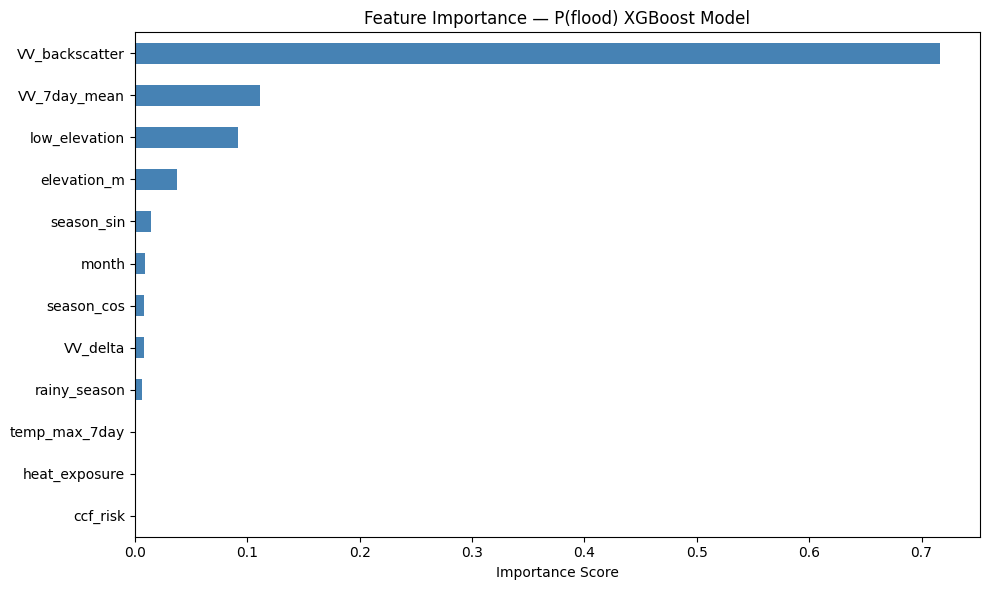

── CDI Scores — Top 20 Highest Risk Facilities ──
       facility_name      state    county      CDI  P_flood risk_level
           KAKA PHCC Upper Nile     Manyo 0.387413 0.249750     Medium
           GUIT PHCC      Unity      Guit 0.308775 0.025070     Medium
          TONGA PHCC Upper Nile Panyikang 0.300055 0.000157     Medium
               N.H.I Upper Nile     Manyo 0.300037 0.000105     Medium
NATIONAL INSURANCE F Upper Nile      Renk 0.300033 0.000095     Medium
         GIEGER PHCC Upper Nile      Renk 0.300030 0.000085     Medium
        WANTHAW PHCC Upper Nile      Renk 0.300028 0.000081     Medium
        WADAKON PHCC Upper Nile     Manyo 0.300026 0.000075     Medium
     N.H.I FUND PHCC Upper Nile      Renk 0.300024 0.000069     Medium
 N.H INSURACE F PHCC Upper Nile      Renk 0.300023 0.000065     Medium
          MELUF PHCC Upper Nile     Melut 0.300016 0.000046     Medium
        NYILUAK PHCC Upper Nile Panyikang 0.300015 0.000043     Medium
          AWETH PHCC Upper 

In [60]:
import matplotlib.pyplot as plt

# ── Feature Importance ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
importances = pd.Series(
    model.feature_importances_,
    index=feature_cols
).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='steelblue')
plt.title('Feature Importance — P(flood) XGBoost Model')
plt.xlabel('Importance Score')
plt.tight_layout()
# Save plot to Drive
plt.savefig(f'{drive_output_path}/feature_importance.png', dpi=150)
plt.show()

# ── Generate CDI Scores for all facilities ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Use the most recent 4 weeks of data as current state
recent = df_model.sort_values('date').groupby('facility_name').tail(4)
recent_features = recent[feature_cols].fillna(0)

recent = recent.copy()
recent['P_flood'] = model.predict_proba(recent_features)[:, 1]

cdi_scores = recent.groupby(['facility_name', 'state', 'county']).agg(
    P_flood=('P_flood', 'mean'),
    avg_VV=('VV_backscatter', 'mean'),
    elevation=('elevation_m', 'first')
).reset_index()

cdi_scores['P_cutoff'] = (cdi_scores['elevation'] < 400).astype(float)

ccf = recent.groupby('facility_name')['ccf_risk'].mean().reset_index()
ccf.columns = ['facility_name', 'P_ccf']
cdi_scores = cdi_scores.merge(ccf, on='facility_name', how='left')

cdi_scores['CDI'] = (0.35 * cdi_scores['P_flood'] + 0.30 * cdi_scores['P_cutoff'] + 0.20 * cdi_scores['P_ccf'])

cdi_scores = cdi_scores.sort_values('CDI', ascending=False).reset_index(drop=True)
cdi_scores['risk_level'] = pd.cut(cdi_scores['CDI'], bins=[0, 0.3, 0.6, 1.0], labels=['Low', 'Medium', 'High'])

print('── CDI Scores — Top 20 Highest Risk Facilities ──')
print(cdi_scores[['facility_name', 'state', 'county', 'CDI', 'P_flood', 'risk_level']].head(20).to_string(index=False))

# Save CDI to Drive
cdi_scores.to_csv(f'{drive_output_path}/CDI_Scores_Current.csv', index=False)

In [62]:
import pickle
import os

# Define the model save path
model_save_path = '/content/drive/MyDrive/Afya_Oracle/final_dataset/SSD_XGBoost_Flood_Model.pkl'

# Save the model using pickle
with open(model_save_path, 'wb') as f:
    pickle.dump(model, f)

print(f'✅ Model successfully saved to Drive!')
print(f'Path: {model_save_path}')

✅ Model successfully saved to Drive!
Path: /content/drive/MyDrive/Afya_Oracle/final_dataset/SSD_XGBoost_Flood_Model.pkl


--- Detailed Risk Profile (Top 10) ---


,facility_name,state,county,CDI,P_flood,avg_VV,elevation
0,KAKA PHCC,Upper Nile,Manyo,0.387413,0.249750,-15.888526,392.160042
1,GUIT PHCC,Unity,Guit,0.308775,0.025070,-16.758737,396.470014
2,TONGA PHCC,Upper Nile,Panyikang,0.300055,0.000157,-11.419030,399.827471
3,N.H.I,Upper Nile,Manyo,0.300037,0.000105,-10.404711,389.719436
4,NATIONAL INSURANCE F,Upper Nile,Renk,0.300033,0.000095,-12.002700,387.609871
5,GIEGER PHCC,Upper Nile,Renk,0.300030,0.000085,-14.512598,385.363876
6,WANTHAW PHCC,Upper Nile,Renk,0.300028,0.000081,-9.774626,387.221493
7,WADAKON PHCC,Upper Nile,Manyo,0.300026,0.000075,-10.080786,388.177551
8,N.H.I FUND PHCC,Upper Nile,Renk,0.300024,0.000069,-9.521582,388.002502
9,N.H INSURACE F PHCC,Upper Nile,Renk,0.300023,0.000065,-7.286544,390.575010


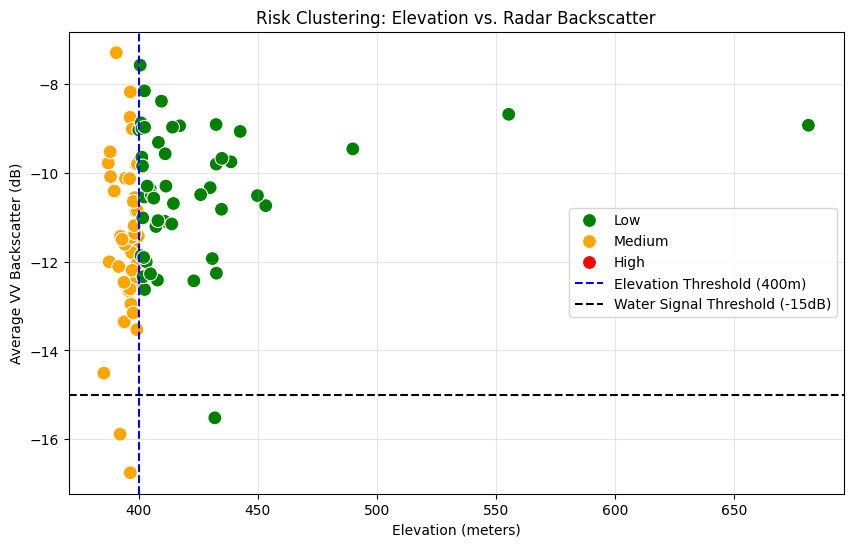

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Summarize the 'Top Risk' facilities with their raw indicators
top_risk_summary = cdi_scores.sort_values('CDI', ascending=False).head(10)

print('--- Detailed Risk Profile (Top 10) ---')
display(top_risk_summary[['facility_name', 'state', 'county', 'CDI', 'P_flood', 'avg_VV', 'elevation']])

# 2. Visualizing the relationship between Elevation and Radar Signal (VV)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=cdi_scores, x='elevation', y='avg_VV', hue='risk_level',
                palette={'Low': 'green', 'Medium': 'orange', 'High': 'red'}, s=100)

plt.axvline(x=400, color='blue', linestyle='--', label='Elevation Threshold (400m)')
plt.axhline(y=-15, color='black', linestyle='--', label='Water Signal Threshold (-15dB)')

plt.title('Risk Clustering: Elevation vs. Radar Backscatter')
plt.xlabel('Elevation (meters)')
plt.ylabel('Average VV Backscatter (dB)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()